In [ ]:
Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import auc
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from captum.attr import IntegratedGradients

In [ ]:
Load, prepare, clean and encode data

In [3]:
data = pd.read_csv('C:\Program Files\Merrimack\DSE6211\Project\project_data.csv')
df = data.drop('Booking_ID', axis=1) 

In [4]:
X = df.drop('booking_status', axis=1)
y = df['booking_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=123)

In [5]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(X_train[['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']])
encoded_df = pd.DataFrame(encoder.transform(X_train[['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']]).toarray(),
                          columns=encoder.get_feature_names_out(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']))
X_train = pd.concat([X_train.drop(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests'], axis=1).reset_index(drop=True), encoded_df], axis=1)
X_train.columns

Index(['market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'lead_time_0', 'lead_time_1',
       'lead_time_2', 'lead_time_3', 'lead_time_4',
       ...
       'avg_price_per_room_349.63', 'avg_price_per_room_365.0',
       'avg_price_per_room_375.5', 'avg_price_per_room_540.0',
       'no_of_special_requests_0', 'no_of_special_requests_1',
       'no_of_special_requests_2', 'no_of_special_requests_3',
       'no_of_special_requests_4', 'no_of_special_requests_5'],
      dtype='object', length=4373)

In [ ]:
Scale and encode data and convert to tensors

In [6]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [7]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_train_tensor

tensor([[-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        ...,
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056,  4.1057,  ..., -0.1382, -0.0470, -0.0149]])

In [8]:
encoded_df = pd.DataFrame(encoder.transform(X_test[['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']]).toarray(),
                          columns=encoder.get_feature_names_out(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']))
X_test = pd.concat([X_test.drop(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests'], axis=1).reset_index(drop=True), encoded_df], axis=1)
X_test.columns

Index(['market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'lead_time_0', 'lead_time_1',
       'lead_time_2', 'lead_time_3', 'lead_time_4',
       ...
       'avg_price_per_room_349.63', 'avg_price_per_room_365.0',
       'avg_price_per_room_375.5', 'avg_price_per_room_540.0',
       'no_of_special_requests_0', 'no_of_special_requests_1',
       'no_of_special_requests_2', 'no_of_special_requests_3',
       'no_of_special_requests_4', 'no_of_special_requests_5'],
      dtype='object', length=4373)

In [9]:
X_test_scaled = scaler.transform(X_test)  
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

In [10]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  
y_test_encoded = encoder.transform(y_test) 

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.float) 
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.float)

In [11]:
y_train_tensor
y_test_tensor

tensor([1., 1., 1.,  ..., 1., 0., 1.])

In [ ]:
Shuffle data and prepare training and test sets for evaluation

In [12]:
n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_indices, val_indices

X_tr = X_train_tensor[train_indices]
y_tr = y_train_tensor[train_indices]
X_val = X_train_tensor[val_indices]
y_val = y_train_tensor[val_indices]

In [ ]:
Final Model using Batch Normalization, Dropout, Regularization, and Patience
RelU and Sigmoid activation function, BCELoss loss function, and RMSProp as the optimizer with stopping on 2000 epochs

In [13]:
seq_model = nn.Sequential(
    nn.Linear(4373, 150),
    nn.BatchNorm1d(150), 
    nn.ReLU(),
    nn.Dropout(0.5), 
    
    nn.Linear(150, 75),
    nn.BatchNorm1d(75),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(75, 1),
    nn.Sigmoid()
)

In [14]:
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val, patience=10):
    best_val_loss = float("inf")
    counter = 0 

    for epoch in range(1, n_epochs + 1):
        seq_model.train() 

        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        seq_model.eval()
        with torch.no_grad():
            X_val_p = model(X_val)
            loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))


        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}, Validation loss {loss_val.item():.4f}")

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)


        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            counter = 0  
        else:
            counter += 1  

        if counter >= patience:
            print(f"Overfitting detected at epoch {epoch}. Training concluded.")
            print(f"Final Epoch: {epoch}, Training Loss: {loss_train.item():.4f}, Validation Loss: {loss_val.item():.4f}")
            break

In [15]:
optimizer = torch.optim.RMSprop(seq_model.parameters(), lr=1e-4, weight_decay=1e-4)
training_loop(
    n_epochs = 2000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.BCELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.6840, Validation loss 0.6838
Epoch 10, Training loss 0.5166, Validation loss 0.5965
Epoch 20, Training loss 0.4328, Validation loss 0.5146
Epoch 30, Training loss 0.3866, Validation loss 0.4748
Epoch 40, Training loss 0.3549, Validation loss 0.4549
Epoch 50, Training loss 0.3299, Validation loss 0.4421
Epoch 60, Training loss 0.3122, Validation loss 0.4326
Epoch 70, Training loss 0.2929, Validation loss 0.4238
Epoch 80, Training loss 0.2782, Validation loss 0.4160
Epoch 90, Training loss 0.2646, Validation loss 0.4090
Epoch 100, Training loss 0.2515, Validation loss 0.4023
Epoch 110, Training loss 0.2408, Validation loss 0.3954
Epoch 120, Training loss 0.2303, Validation loss 0.3895
Epoch 130, Training loss 0.2205, Validation loss 0.3841
Epoch 140, Training loss 0.2107, Validation loss 0.3791
Epoch 150, Training loss 0.2035, Validation loss 0.3740
Epoch 160, Training loss 0.1954, Validation loss 0.3699
Epoch 170, Training loss 0.1869, Validation loss 0.3661
Epo

In [16]:
seq_model(X_test_tensor).detach().numpy()

array([[0.94555795],
       [0.94871026],
       [0.9244116 ],
       ...,
       [0.97000116],
       [0.00560132],
       [0.8507167 ]], dtype=float32)

In [ ]:
Final Model predictions, ROC AUC, Calibration Plot, and Feature Importance

In [17]:
p_1_actual = pd.DataFrame({'p_1': seq_model(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test_encoded})
p_1_actual.head()

,p_1,actual
0,0.945558,1
1,0.948710,1
2,0.924412,1
3,0.348367,1
4,0.950845,1


In [18]:
roc_list = []

actuals_0 = (p_1_actual['actual'] == 0).sum()
actuals_1 = (p_1_actual['actual'] == 1).sum()

for i in np.arange(1, -0.01, -0.01):

    over_threshold = p_1_actual[p_1_actual['p_1'] >= i]
    
    fp = (over_threshold['actual'] == 0).sum()
    tp = (over_threshold['actual'] == 1).sum()

    fpr = fp / actuals_0 if actuals_0 > 0 else 0.0
    tpr = tp / actuals_1 if actuals_1 > 0 else 0.0
    
    roc_list.append((i, fpr, tpr))

roc_data = pd.DataFrame(roc_list, columns=['threshold', 'fpr', 'tpr'])

roc_data
  

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.000000
1,9.900000e-01,0.001366,0.031969
2,9.800000e-01,0.004097,0.085957
3,9.700000e-01,0.006145,0.154461
4,9.600000e-01,0.009560,0.259827
...,...,...,...
96,4.000000e-02,0.626494,0.995922
97,3.000000e-02,0.704677,0.997227
98,2.000000e-02,0.865483,0.997880
99,1.000000e-02,0.936156,0.999184


In [19]:
roc_auc = auc(roc_data['fpr'], roc_data['tpr'])
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.9245


In [20]:
predicted_labels = (p_1_actual['p_1'] >= 0.5).astype(int)

accuracy = (predicted_labels == p_1_actual['actual']).mean()

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8599


In [21]:
y_pred_probs = seq_model(X_test_tensor).detach().numpy()

y_pred = (y_pred_probs >= 0.5).astype(int)

y_true = y_test_tensor.numpy().astype(int)

In [22]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9067
Recall: 0.8840


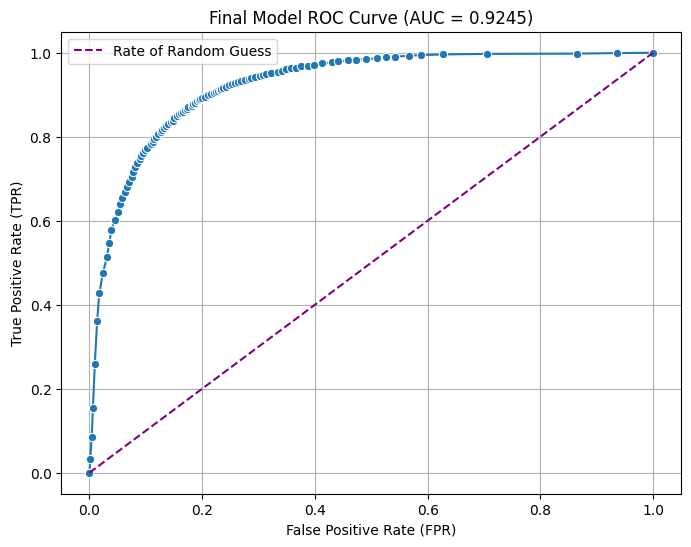

In [81]:
plt.figure(figsize=(8, 6))
roc = sns.lineplot(x='fpr', y='tpr', data=roc_data, marker='o', linestyle='-')

xlims = roc.get_xlim()
ylims = roc.get_ylim()

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.plot([0, 1], [0, 1], linestyle='--', color='purple', label="Rate of Random Guess")

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Final Model ROC Curve (AUC = {roc_auc:.4f})') 
plt.legend()
plt.grid()

plt.show()

In [69]:
calibration_data = pd.DataFrame({'bin_midpoint': np.arange(0.05, 0.96, 0.1),
                                 'observed_event_percentage': 0.0})
for i in np.arange(0.05, 0.96, 0.1):

    in_interval = p_1_actual[(p_1_actual['p_1'] >= (i-0.05)) & (p_1_actual['p_1'] <= (i+0.05))].copy()
    in_interval['actual'] = in_interval['actual'].astype(int)
    num_positive_in_interval = len(in_interval.loc[in_interval['actual'] == 1])
    num_in_interval = len(in_interval)

    oep = num_positive_in_interval/num_in_interval
    
    calibration_data.loc[calibration_data['bin_midpoint'] == i, 'observed_event_percentage'] = oep

calibration_data

,bin_midpoint,observed_event_percentage
0,0.05,0.060377
1,0.15,0.252874
2,0.25,0.421751
3,0.35,0.511475
4,0.45,0.583333
5,0.55,0.672897
6,0.65,0.735149
7,0.75,0.807207
8,0.85,0.879227
9,0.95,0.968878


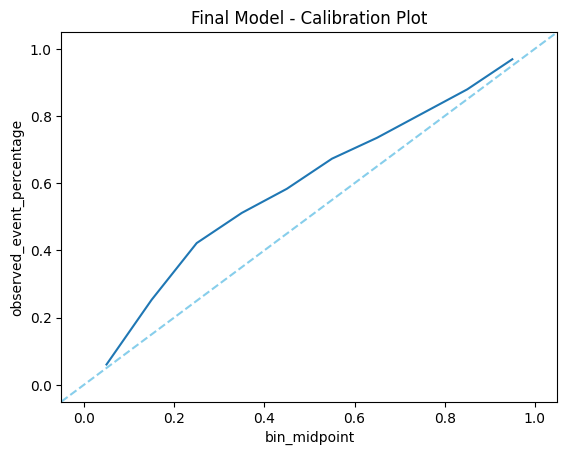

In [89]:
roc = sns.lineplot(x='bin_midpoint', y='observed_event_percentage', data=calibration_data)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

xlims = roc.get_xlim()
ylims = roc.get_ylim()

min_val = min(xlims[0], ylims[0])
max_val = max(xlims[1], ylims[1])

roc.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='skyblue')

roc.set_xlim(xlims)
roc.set_ylim(ylims)

plt.title(f'Final Model - Calibration Plot') 

plt.show()

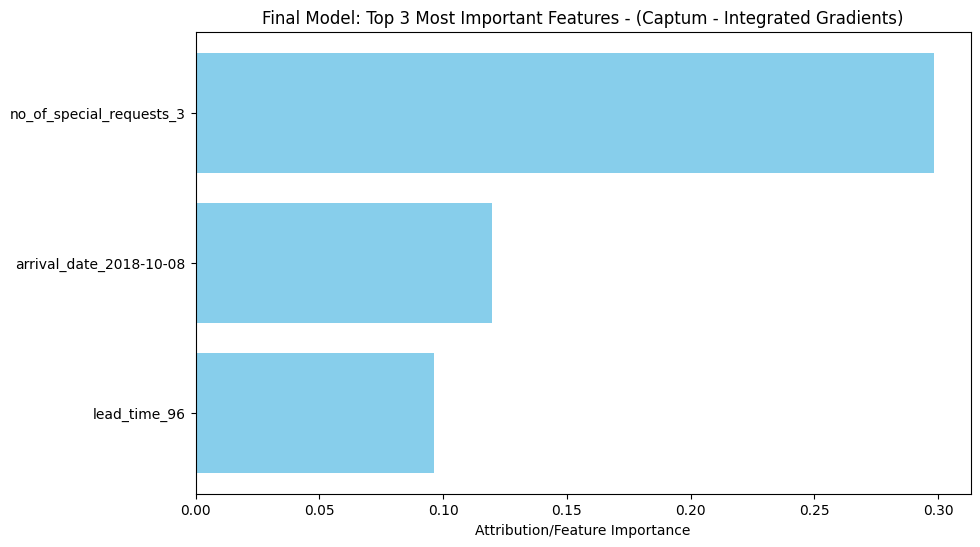

In [87]:
seq_model.eval()

X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)


integrated_gradients = IntegratedGradients(seq_model)


input_tensor = X_test_tensor[0].unsqueeze(0)  


attributions, delta = integrated_gradients.attribute(input_tensor, target=0, return_convergence_delta=True)


attributions = attributions.squeeze().cpu().detach().numpy()


feature_names = X_test_scaled.columns  
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(attributions) 
})


feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)


top_3_features = feature_importance_df.head(3)


plt.figure(figsize=(10, 6))
plt.barh(top_3_features['Feature'], top_3_features['Importance'], color='skyblue')
plt.xlabel("Attribution/Feature Importance")
plt.title("Final Model: Top 3 Most Important Features - (Captum - Integrated Gradients)")
plt.gca().invert_yaxis()  
plt.show()


In [ ]:
Model 2 using Patience, RelU and Sigmoid activation function, BCELoss loss function, 
and RMSProp as the optimizer with stopping on 5000 epochs

In [25]:
seq_model2 = nn.Sequential(
    nn.Linear(4373, 300),
    nn.ReLU(),
    nn.Linear(300, 150),
    nn.ReLU(),
    nn.Linear(150, 1),
    nn.Sigmoid()
)

In [26]:
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val, patience=15):
    best_val_loss = float("inf")
    counter = 0 

    for epoch in range(1, n_epochs + 1):
        seq_model2.train() 

        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        seq_model2.eval()
        with torch.no_grad():
            X_val_p = model(X_val)
            loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))


        if epoch == 1 or epoch % 100 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}, Validation loss {loss_val.item():.4f}")


In [27]:
optimizer2 = optim.RMSprop(seq_model2.parameters(), lr=1e-3)
training_loop(
    n_epochs = 5000,
    optimizer = optimizer2,
    model = seq_model2,
    loss_fn = nn.BCELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.7248, Validation loss 1.0343
Epoch 100, Training loss 0.0141, Validation loss 1.8579
Epoch 200, Training loss 0.0123, Validation loss 2.1920
Epoch 300, Training loss 0.0120, Validation loss 2.3963
Epoch 400, Training loss 0.0116, Validation loss 2.4212
Epoch 500, Training loss 0.0112, Validation loss 2.5091
Epoch 600, Training loss 0.0110, Validation loss 2.5242
Epoch 700, Training loss 0.0109, Validation loss 2.6425
Epoch 800, Training loss 0.0106, Validation loss 2.6914
Epoch 900, Training loss 0.0107, Validation loss 2.7362
Epoch 1000, Training loss 0.0150, Validation loss 3.0125
Epoch 1100, Training loss 0.0149, Validation loss 3.5907
Epoch 1200, Training loss 0.0149, Validation loss 3.7614
Epoch 1300, Training loss 0.0149, Validation loss 3.8648
Epoch 1400, Training loss 0.0150, Validation loss 3.9081
Epoch 1500, Training loss 0.0150, Validation loss 3.8977
Epoch 1600, Training loss 0.0150, Validation loss 3.8718
Epoch 1700, Training loss 0.0150, Validatio

In [28]:
seq_model2(X_test_tensor).detach().numpy()

array([[1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       ...,
       [1.0000000e+00],
       [1.5568187e-18],
       [9.9999988e-01]], dtype=float32)

In [ ]:
Model 2 predictions, ROC AUC, Calibration Plot, and Feature Importance


In [29]:
p_1_actual2 = pd.DataFrame({'p_1': seq_model2(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test_encoded})
p_1_actual2.head()

,p_1,actual
0,1.000000,1
1,1.000000,1
2,1.000000,1
3,0.000009,1
4,1.000000,1


In [30]:
roc_list2 = []

actuals_02 = (p_1_actual2['actual'] == 0).sum()
actuals_12 = (p_1_actual2['actual'] == 1).sum()

for i in np.arange(1, -0.01, -0.01):

    over_threshold2 = p_1_actual2[p_1_actual2['p_1'] >= i]
    
    fp2 = (over_threshold2['actual'] == 0).sum()
    tp2 = (over_threshold2['actual'] == 1).sum()

    fpr2 = fp2 / actuals_02 if actuals_02 > 0 else 0.0
    tpr2 = tp2 / actuals_12 if actuals_12 > 0 else 0.0
    
    roc_list2.append((i, fpr2, tpr2))

roc_data2 = pd.DataFrame(roc_list2, columns=['threshold', 'fpr', 'tpr'])

roc_data2

,threshold,fpr,tpr
0,1.000000e+00,0.097986,0.594683
1,9.900000e-01,0.221919,0.885174
2,9.800000e-01,0.226699,0.893003
3,9.700000e-01,0.230795,0.896428
4,9.600000e-01,0.231137,0.897896
...,...,...,...
96,4.000000e-02,0.316149,0.946828
97,3.000000e-02,0.319222,0.947969
98,2.000000e-02,0.322294,0.949274
99,1.000000e-02,0.326733,0.951068


In [31]:
roc_auc2 = auc(roc_data2['fpr'], roc_data2['tpr'])
print(f"ROC AUC Score: {roc_auc2:.4f}")

ROC AUC Score: 0.8457


In [32]:
predicted_labels2 = (p_1_actual2['p_1'] >= 0.5).astype(int)

accuracy2 = (predicted_labels2 == p_1_actual2['actual']).mean()

print(f"Accuracy: {accuracy2:.4f}")

Accuracy: 0.8664


In [33]:
y_pred_probs2 = seq_model2(X_test_tensor).detach().numpy()

y_pred2 = (y_pred_probs2 >= 0.5).astype(int)

y_true2 = y_test_tensor.numpy().astype(int)

In [34]:
from sklearn.metrics import precision_score, recall_score

precision2 = precision_score(y_true2, y_pred2)
recall2 = recall_score(y_true2, y_pred2)

print(f"Precision: {precision2:.4f}")
print(f"Recall: {recall2:.4f}")

Precision: 0.8785
Recall: 0.9315


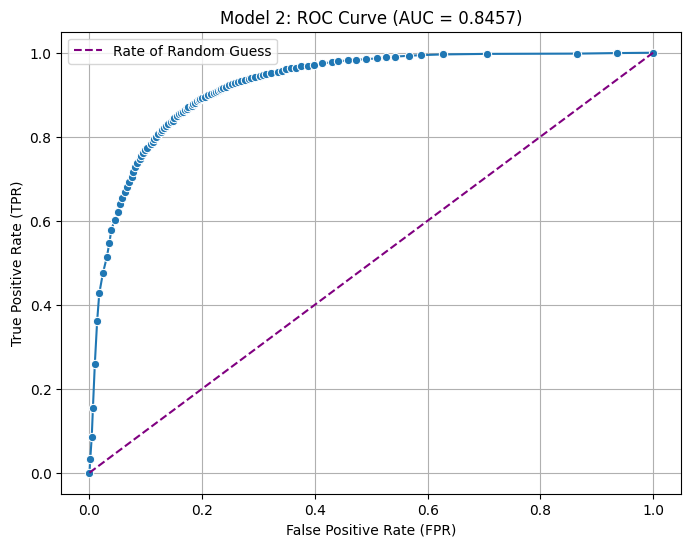

In [99]:
plt.figure(figsize=(8, 6))
roc2 = sns.lineplot(x='fpr', y='tpr', data=roc_data, marker='o', linestyle='-')

xlims2 = roc.get_xlim()
ylims2 = roc.get_ylim()

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.plot([0, 1], [0, 1], linestyle='--', color='purple', label="Rate of Random Guess")

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Model 2: ROC Curve (AUC = {roc_auc2:.4f})') 
plt.legend()
plt.grid()

plt.show()

In [66]:
calibration_data2 = pd.DataFrame({'bin_midpoint': np.arange(0.05, 0.96, 0.1),
                                 'observed_event_percentage': 0.0})
for i in np.arange(0.05, 0.96, 0.1):

    in_interval2 = p_1_actual2[(p_1_actual2['p_1'] >= (i-0.05)) & (p_1_actual2['p_1'] <= (i+0.05))].copy()
    in_interval2['actual'] = in_interval2['actual'].astype(int)
    num_positive_in_interval2 = len(in_interval2.loc[in_interval2['actual'] == 1])
    num_in_interval2 = len(in_interval2)

    oep2 = num_positive_in_interval2/num_in_interval2
    
    calibration_data2.loc[calibration_data2['bin_midpoint'] == i, 'observed_event_percentage'] = oep2

calibration_data2

,bin_midpoint,observed_event_percentage
0,0.05,0.144477
1,0.15,0.524590
2,0.25,0.333333
3,0.35,0.400000
4,0.45,0.393939
5,0.55,0.642857
6,0.65,0.586207
7,0.75,0.483871
8,0.85,0.693182
9,0.95,0.886753


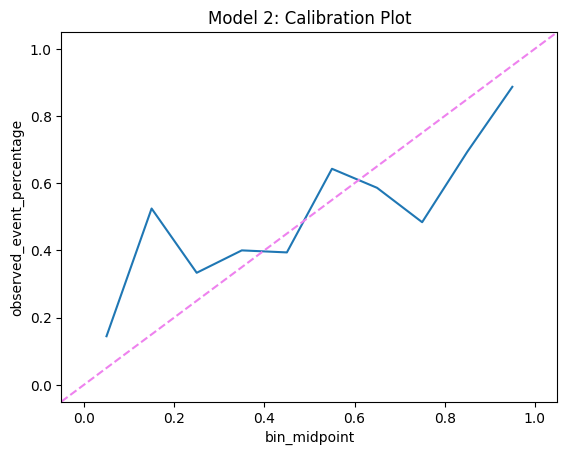

In [88]:
roc2 = sns.lineplot(x='bin_midpoint', y='observed_event_percentage', data=calibration_data2)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

xlims2 = roc2.get_xlim()
ylims2 = roc2.get_ylim()

min_val2 = min(xlims2[0], ylims2[0])
max_val2 = max(xlims2[1], ylims2[1])

roc2.plot([min_val2, max_val2], [min_val2, max_val2], linestyle='--', color='violet')

roc2.set_xlim(xlims2)
roc2.set_ylim(ylims2)

plt.title(f'Model 2 - Calibration Plot') 
plt.show()

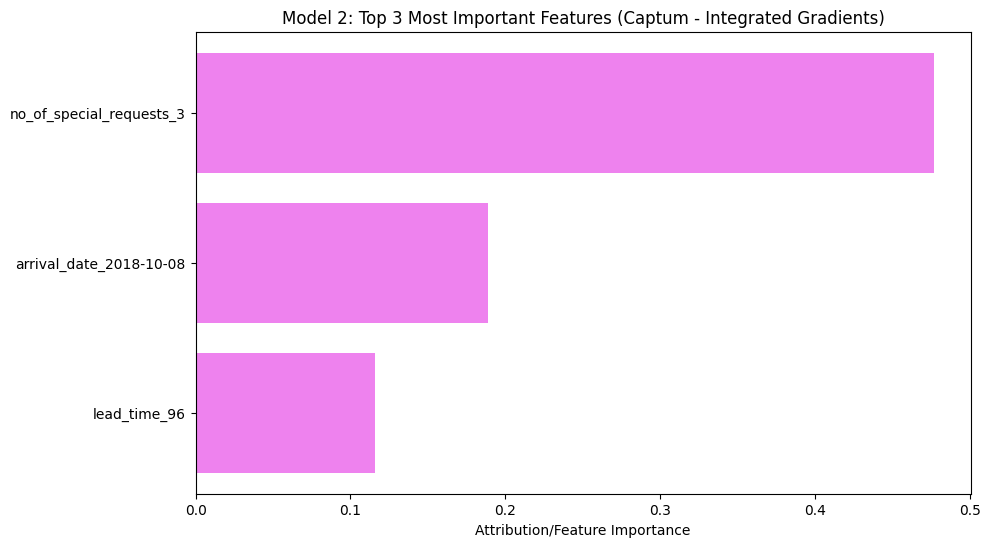

In [90]:
seq_model2.eval()

X_test_tensor2 = torch.tensor(X_test_scaled.values, dtype=torch.float32)


integrated_gradients2 = IntegratedGradients(seq_model2)


input_tensor2 = X_test_tensor2[0].unsqueeze(0)  

attributions2, delta2 = integrated_gradients2.attribute(input_tensor2, target=0, return_convergence_delta=True)

attributions2 = attributions2.squeeze().cpu().detach().numpy()

feature_names2 = X_test_scaled.columns 
feature_importance_df2 = pd.DataFrame({
    "Feature": feature_names2,
    "Importance": np.abs(attributions2) 
})


feature_importance_df2 = feature_importance_df2.sort_values(by="Importance", ascending=False)


top_3_features2 = feature_importance_df2.head(3)

plt.figure(figsize=(10, 6))
plt.barh(top_3_features2['Feature'], top_3_features2['Importance'], color='violet')
plt.xlabel("Attribution/Feature Importance")
plt.title("Model 2: Top 3 Most Important Features (Captum - Integrated Gradients)")
plt.gca().invert_yaxis()  # Highest importance at top
plt.show()

In [ ]:
Model 3 using Patience, Tanh and Sigmoid activation function, MSELoss loss function, 
and RMSProp as the optimizer with 5000 epochs

In [37]:
seq_model3 = nn.Sequential(
    nn.Linear(4373, 300),
    nn.Tanh(),
    nn.Linear(300, 150),
    nn.Tanh(),
    nn.Linear(150, 1),
    nn.Sigmoid()
)

In [38]:
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val, patience=15):
    best_val_loss = float("inf")
    counter = 0 

    for epoch in range(1, n_epochs + 1):
        seq_model3.train() 

        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        seq_model3.eval()
        with torch.no_grad():
            X_val_p = model(X_val)
            loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))


        if epoch == 1 or epoch % 100 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}, Validation loss {loss_val.item():.4f}")

In [39]:
optimizer3 = optim.RMSprop(seq_model3.parameters(), lr=1e-3)
training_loop(
    n_epochs = 5000,
    optimizer = optimizer3,
    model = seq_model3,
    loss_fn = nn.MSELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.2498, Validation loss 0.1973
Epoch 100, Training loss 0.0181, Validation loss 0.1661
Epoch 200, Training loss 0.0155, Validation loss 0.1704
Epoch 300, Training loss 0.0149, Validation loss 0.1693
Epoch 400, Training loss 0.0142, Validation loss 0.1703
Epoch 500, Training loss 0.0136, Validation loss 0.1695
Epoch 600, Training loss 0.0134, Validation loss 0.1698
Epoch 700, Training loss 0.0132, Validation loss 0.1707
Epoch 800, Training loss 0.0123, Validation loss 0.1696
Epoch 900, Training loss 0.0118, Validation loss 0.1703
Epoch 1000, Training loss 0.0116, Validation loss 0.1699
Epoch 1100, Training loss 0.0112, Validation loss 0.1695
Epoch 1200, Training loss 0.0108, Validation loss 0.1699
Epoch 1300, Training loss 0.0103, Validation loss 0.1687
Epoch 1400, Training loss 0.0098, Validation loss 0.1702
Epoch 1500, Training loss 0.0094, Validation loss 0.1703
Epoch 1600, Training loss 0.0090, Validation loss 0.1708
Epoch 1700, Training loss 0.0088, Validatio

In [40]:
seq_model3(X_test_tensor).detach().numpy()

array([[9.9987459e-01],
       [9.9986017e-01],
       [9.9953663e-01],
       ...,
       [9.9979538e-01],
       [9.9613600e-05],
       [9.9987555e-01]], dtype=float32)

In [ ]:
Model 3 predictions, ROC AUC, Calibration Plot, and Feature Importance

In [41]:
p_1_actual3 = pd.DataFrame({'p_1': seq_model3(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test_encoded})
p_1_actual3.head()

,p_1,actual
0,0.999875,1
1,0.999860,1
2,0.999537,1
3,0.004278,1
4,0.999627,1


In [42]:
roc_list3 = []

actuals_03 = (p_1_actual3['actual'] == 0).sum()
actuals_13 = (p_1_actual3['actual'] == 1).sum()

for i in np.arange(1, -0.01, -0.01):

    over_threshold3 = p_1_actual3[p_1_actual3['p_1'] >= i]
    
    fp3 = (over_threshold3['actual'] == 0).sum()
    tp3 = (over_threshold3['actual'] == 1).sum()

    fpr3 = fp3 / actuals_03 if actuals_03 > 0 else 0.0
    tpr3 = tp3 / actuals_13 if actuals_13 > 0 else 0.0
    
    roc_list3.append((i, fpr3, tpr3))

roc_data3 = pd.DataFrame(roc_list3, columns=['threshold', 'fpr', 'tpr'])

roc_data3

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.000000
1,9.900000e-01,0.125982,0.766596
2,9.800000e-01,0.134517,0.782417
3,9.700000e-01,0.140321,0.792367
4,9.600000e-01,0.143394,0.797423
...,...,...,...
96,4.000000e-02,0.272789,0.906214
97,3.000000e-02,0.278935,0.909476
98,2.000000e-02,0.290201,0.913554
99,1.000000e-02,0.311369,0.921709


In [43]:
roc_auc3 = auc(roc_data3['fpr'], roc_data3['tpr'])
print(f"ROC AUC Score: {roc_auc3:.4f}")

ROC AUC Score: 0.8702


In [44]:
predicted_labels3 = (p_1_actual3['p_1'] >= 0.5).astype(int)

accuracy3 = (predicted_labels3 == p_1_actual3['actual']).mean()

print(f"Accuracy: {accuracy3:.4f}")

Accuracy: 0.8411


In [45]:
y_pred_probs3 = seq_model3(X_test_tensor).detach().numpy()

y_pred3 = (y_pred_probs3 >= 0.5).astype(int)

y_true3 = y_test_tensor.numpy().astype(int)

In [46]:
from sklearn.metrics import precision_score, recall_score

precision3 = precision_score(y_true3, y_pred3)
recall3 = recall_score(y_true3, y_pred3)

print(f"Precision: {precision3:.4f}")
print(f"Recall: {recall3:.4f}")

Precision: 0.8969
Recall: 0.8645


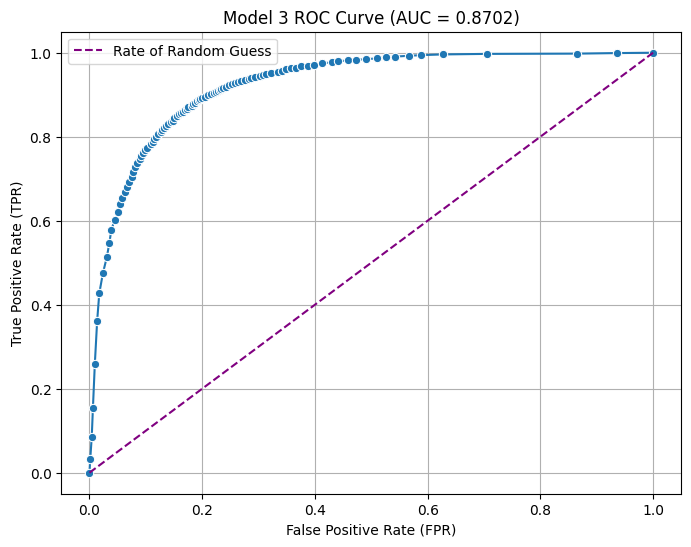

In [91]:
plt.figure(figsize=(8, 6))
roc3 = sns.lineplot(x='fpr', y='tpr', data=roc_data, marker='o', linestyle='-')

xlims3 = roc.get_xlim()
ylims3 = roc.get_ylim()

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.plot([0, 1], [0, 1], linestyle='--', color='purple', label="Rate of Random Guess")

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Model 3 ROC Curve (AUC = {roc_auc3:.4f})') 
plt.legend()
plt.grid()

plt.show()

In [48]:
calibration_data3 = pd.DataFrame({'bin_midpoint': np.arange(0.05, 0.96, 0.1),
                                 'observed_event_percentage': 0.0})
for i in np.arange(0.05, 0.96, 0.1):

    in_interval3 = p_1_actual3[(p_1_actual3['p_1'] >= (i-0.05)) & (p_1_actual3['p_1'] <= (i+0.05))].copy()
    in_interval3['actual'] = in_interval3['actual'].astype(int)
    num_positive_in_interval3 = len(in_interval3.loc[in_interval3['actual'] == 1])
    num_in_interval3 = len(in_interval3)

    oep3 = num_positive_in_interval3/num_in_interval3
    
    calibration_data3.loc[calibration_data3['bin_midpoint'] == i, 'observed_event_percentage'] = oep3

calibration_data3

,bin_midpoint,observed_event_percentage
0,0.05,0.229005
1,0.15,0.592233
2,0.25,0.600000
3,0.35,0.539474
4,0.45,0.555556
5,0.55,0.581081
6,0.65,0.656566
7,0.75,0.670732
8,0.85,0.701389
9,0.95,0.913975


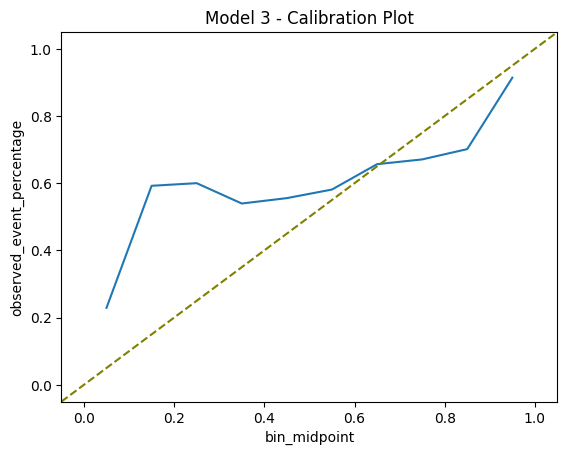

In [92]:
roc3 = sns.lineplot(x='bin_midpoint', y='observed_event_percentage', data=calibration_data3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

xlims3 = roc3.get_xlim()
ylims3 = roc3.get_ylim()

min_val3 = min(xlims3[0], ylims3[0])
max_val3 = max(xlims3[1], ylims3[1])

roc3.plot([min_val3, max_val3], [min_val3, max_val3], linestyle='--', color='olive')

roc3.set_xlim(xlims3)
roc3.set_ylim(ylims3)

plt.title(f'Model 3 - Calibration Plot') 

plt.show()

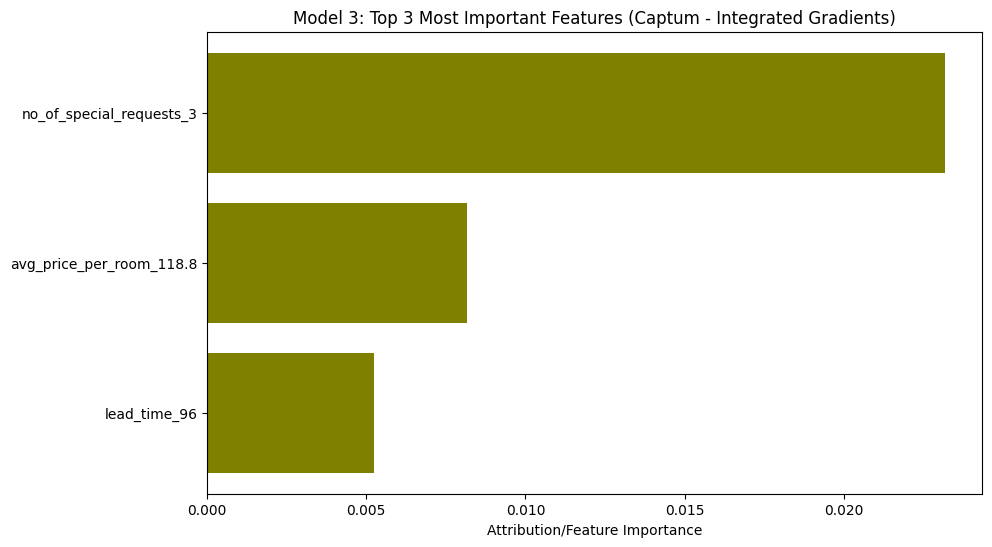

In [96]:
seq_model3.eval()

X_test_tensor3 = torch.tensor(X_test_scaled.values, dtype=torch.float32)

integrated_gradients3 = IntegratedGradients(seq_model3)

input_tensor3 = X_test_tensor3[0].unsqueeze(0) 

attributions3, delta3 = integrated_gradients3.attribute(input_tensor3, target=0, return_convergence_delta=True)

attributions3 = attributions3.squeeze().cpu().detach().numpy()

feature_names3 = X_test_scaled.columns 
feature_importance_df3 = pd.DataFrame({
    "Feature": feature_names3,
    "Importance": np.abs(attributions3)  
})

feature_importance_df3 = feature_importance_df3.sort_values(by="Importance", ascending=False)

top_3_features3 = feature_importance_df3.head(3)

plt.figure(figsize=(10, 6))
plt.barh(top_3_features3['Feature'], top_3_features3['Importance'], color='olive')
plt.xlabel("Attribution/Feature Importance")
plt.title("Model 3: Top 3 Most Important Features (Captum - Integrated Gradients)")
plt.gca().invert_yaxis()  
plt.show()

In [ ]:
Model 4 using Patience, Tanh and Sigmoid activation function, MSELoss loss function, 
and Adam as the optimizer with stopping on 200 epochs

In [97]:
seq_model4 = nn.Sequential(
    nn.Linear(4373, 100),
    nn.Tanh(),
    nn.Dropout(0.5),  
    nn.Linear(100, 50),
    nn.Tanh(),
    nn.Dropout(0.5),  
    nn.Linear(50, 1),
    nn.Sigmoid()
)


In [52]:
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val, patience=100):
    best_val_loss = float("inf")
    counter = 0 

    for epoch in range(1, n_epochs + 1):
        seq_model4.train() 

        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        seq_model4.eval()
        with torch.no_grad():
            X_val_p = model(X_val)
            loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))


        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}, Validation loss {loss_val.item():.4f}")

        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            counter = 0  
        else:
            counter += 1  

        if counter >= patience:
            print(f"Overfitting detected at epoch {epoch}. Training concluded.")
            print(f"Final Epoch: {epoch}, Training Loss: {loss_train.item():.4f}, Validation Loss: {loss_val.item():.4f}")
            break

In [53]:
optimizer4 = optimizer = optim.Adam(seq_model4.parameters(), lr=1e-3, weight_decay=1e-4)
training_loop(
    n_epochs = 200,
    optimizer = optimizer4,
    model = seq_model4,
    loss_fn = nn.MSELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.2664, Validation loss 0.2533
Epoch 10, Training loss 0.1567, Validation loss 0.1975
Epoch 20, Training loss 0.1060, Validation loss 0.1830
Epoch 30, Training loss 0.0857, Validation loss 0.1764
Epoch 40, Training loss 0.0746, Validation loss 0.1705
Epoch 50, Training loss 0.0680, Validation loss 0.1660
Epoch 60, Training loss 0.0646, Validation loss 0.1636
Epoch 70, Training loss 0.0613, Validation loss 0.1625
Epoch 80, Training loss 0.0586, Validation loss 0.1620
Epoch 90, Training loss 0.0562, Validation loss 0.1619
Epoch 100, Training loss 0.0539, Validation loss 0.1613
Epoch 110, Training loss 0.0529, Validation loss 0.1615
Epoch 120, Training loss 0.0505, Validation loss 0.1608
Epoch 130, Training loss 0.0490, Validation loss 0.1608
Epoch 140, Training loss 0.0482, Validation loss 0.1612
Epoch 150, Training loss 0.0455, Validation loss 0.1617
Epoch 160, Training loss 0.0440, Validation loss 0.1612
Epoch 170, Training loss 0.0426, Validation loss 0.1613
Epo

In [54]:
seq_model4(X_test_tensor).detach().numpy()

array([[0.99763656],
       [0.99344313],
       [0.9439868 ],
       ...,
       [0.9986205 ],
       [0.00111948],
       [0.9438613 ]], dtype=float32)

In [ ]:
Model 4 predictions, ROC AUC, Calibration Plot, and Feature Importance

In [55]:
p_1_actual4 = pd.DataFrame({'p_1': seq_model4(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test_encoded})
p_1_actual4.head()

,p_1,actual
0,0.997637,1
1,0.993443,1
2,0.943987,1
3,0.388076,1
4,0.995000,1


In [56]:
roc_list4 = []

actuals_04 = (p_1_actual4['actual'] == 0).sum()
actuals_14 = (p_1_actual4['actual'] == 1).sum()

for i in np.arange(1, -0.01, -0.01):

    over_threshold4 = p_1_actual4[p_1_actual4['p_1'] >= i]
    
    fp4 = (over_threshold4['actual'] == 0).sum()
    tp4 = (over_threshold4['actual'] == 1).sum()

    fpr4 = fp4 / actuals_04 if actuals_04 > 0 else 0.0
    tpr4 = tp4 / actuals_14 if actuals_14 > 0 else 0.0
    
    roc_list4.append((i, fpr4, tpr4))

roc_data4 = pd.DataFrame(roc_list4, columns=['threshold', 'fpr', 'tpr'])

roc_data4

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.000000
1,9.900000e-01,0.064527,0.573153
2,9.800000e-01,0.081256,0.657478
3,9.700000e-01,0.092182,0.694014
4,9.600000e-01,0.101741,0.718969
...,...,...,...
96,4.000000e-02,0.395698,0.934758
97,3.000000e-02,0.430181,0.939488
98,2.000000e-02,0.482076,0.945686
99,1.000000e-02,0.572209,0.954983


In [57]:
roc_auc4 = auc(roc_data4['fpr'], roc_data4['tpr'])
print(f"ROC AUC Score: {roc_auc4:.4f}")

ROC AUC Score: 0.8864


In [58]:
predicted_labels4 = (p_1_actual4['p_1'] >= 0.5).astype(int)

accuracy4 = (predicted_labels4 == p_1_actual4['actual']).mean()

print(f"Accuracy: {accuracy4:.4f}")

Accuracy: 0.8478


In [59]:
y_pred_probs4 = seq_model4(X_test_tensor).detach().numpy()

y_pred4 = (y_pred_probs4 >= 0.5).astype(int)

y_true4 = y_test_tensor.numpy().astype(int)


In [60]:
precision4 = precision_score(y_true4, y_pred4)
recall4 = recall_score(y_true4, y_pred4)

print(f"Precision: {precision4:.4f}")
print(f"Recall: {recall4:.4f}")


Precision: 0.9023
Recall: 0.8692


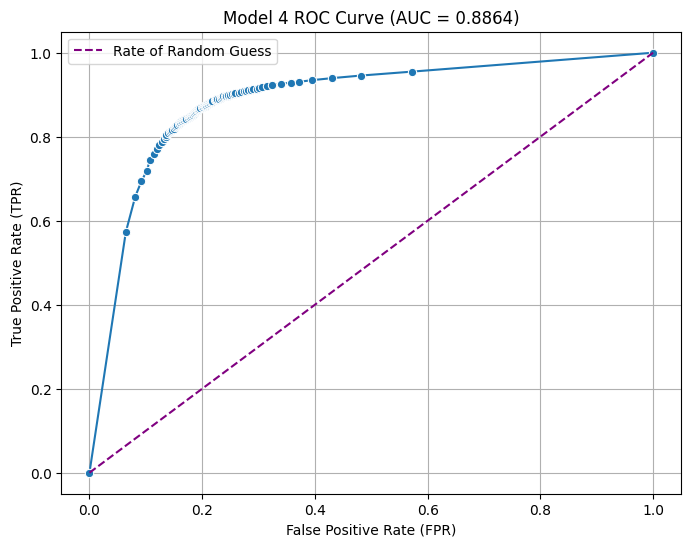

In [93]:
plt.figure(figsize=(8, 6))
roc4 = sns.lineplot(x='fpr', y='tpr', data=roc_data4, marker='o', linestyle='-')

xlims4 = roc.get_xlim()
ylims4 = roc.get_ylim()

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.plot([0, 1], [0, 1], linestyle='--', color='purple', label="Rate of Random Guess")

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Model 4 ROC Curve (AUC = {roc_auc4:.4f})') 
plt.legend()
plt.grid()

plt.show()

In [63]:
calibration_data4 = pd.DataFrame({'bin_midpoint': np.arange(0.05, 0.96, 0.1),
                                 'observed_event_percentage': 0.0})
for i in np.arange(0.05, 0.96, 0.1):

    in_interval4 = p_1_actual4[(p_1_actual4['p_1'] >= (i-0.05)) & (p_1_actual4['p_1'] <= (i+0.05))].copy()
    in_interval4['actual'] = in_interval4['actual'].astype(int)
    num_positive_in_interval4 = len(in_interval4.loc[in_interval4['actual'] == 1])
    num_in_interval4 = len(in_interval4)

    oep4 = num_positive_in_interval4/num_in_interval4
    
    calibration_data4.loc[calibration_data4['bin_midpoint'] == i, 'observed_event_percentage'] = oep4

calibration_data4

,bin_midpoint,observed_event_percentage
0,0.05,0.198266
1,0.15,0.391111
2,0.25,0.467153
3,0.35,0.548872
4,0.45,0.606557
5,0.55,0.693069
6,0.65,0.700000
7,0.75,0.652174
8,0.85,0.749104
9,0.95,0.926356


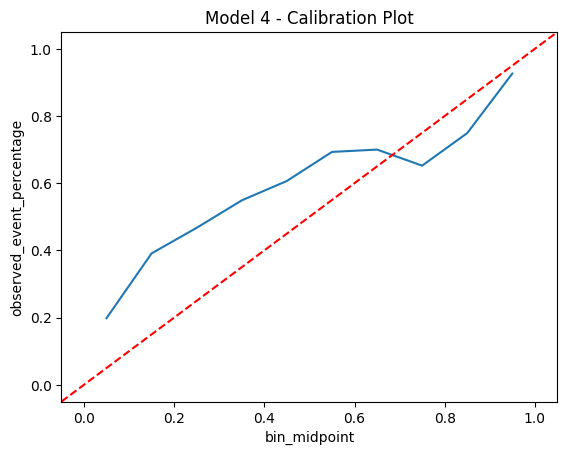

In [95]:
roc4 = sns.lineplot(x='bin_midpoint', y='observed_event_percentage', data=calibration_data4)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

xlims4 = roc4.get_xlim()
ylims4 = roc4.get_ylim()

min_val4 = min(xlims4[0], ylims4[0])
max_val4 = max(xlims4[1], ylims4[1])

roc4.plot([min_val4, max_val4], [min_val4, max_val4], linestyle='--', color='red')

roc4.set_xlim(xlims4)
roc4.set_ylim(ylims4)

plt.title(f'Model 4 - Calibration Plot') 

plt.show()

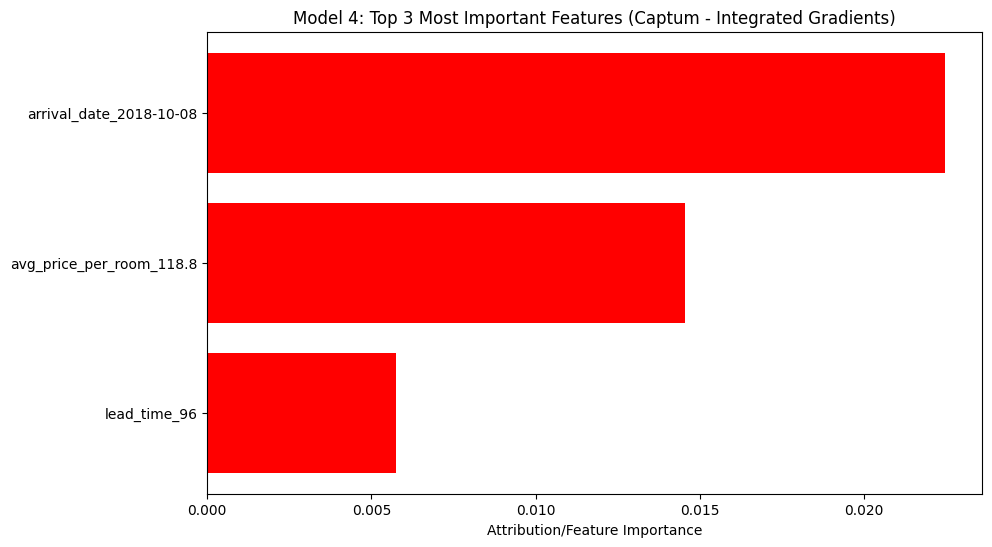

In [98]:
seq_model4.eval()

X_test_tensor4 = torch.tensor(X_test_scaled.values, dtype=torch.float32)

integrated_gradients4 = IntegratedGradients(seq_model4)

input_tensor4 = X_test_tensor4[0].unsqueeze(0) 

attributions4, delta4 = integrated_gradients4.attribute(input_tensor4, target=0, return_convergence_delta=True)

attributions4 = attributions4.squeeze().cpu().detach().numpy()

feature_names4 = X_test_scaled.columns  
feature_importance_df4 = pd.DataFrame({
    "Feature": feature_names4,
    "Importance": np.abs(attributions4)  
})

feature_importance_df4 = feature_importance_df4.sort_values(by="Importance", ascending=False)

top_3_features4 = feature_importance_df4.head(3)

plt.figure(figsize=(10, 6))
plt.barh(top_3_features4['Feature'], top_3_features4['Importance'], color='red')
plt.xlabel("Attribution/Feature Importance")
plt.title("Model 4: Top 3 Most Important Features (Captum - Integrated Gradients)")
plt.gca().invert_yaxis() 
plt.show()